# Tahap Preprocessing (Tanpa CLAHE)

Notebook ini digunakan untuk:
1. Mendesain dan menguji pipeline preprocessing (resize, normalisasi, augmentasi) tanpa CLAHE.
2. Menampilkan contoh gambar sebelum/sesudah preprocessing (minimal 10 gambar).
3. Menyiapkan fungsi yang nanti akan dipakai di tahap training Swin Transformer.

# IMPORT LIBRARY YANG DI BUTUHKAN

In [13]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # untuk menghindari error pada beberapa sistem dan memakai dua dua versi library OpenMP 
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A  
import torch
import torchvision
from albumentations.pytorch import ToTensorV2 # Tambahan untuk augmentasi

from skimage.feature import graycomatrix, graycoprops
from PIL import Image

# Tampilkan gambar inline
%matplotlib inline


def seed_everything(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# Path dataset (sesuaikan jika berbeda)
DATASET_ROOT = r"C:\kuliah-sementara\SKRIPSI\Dataset_MRL_SPLIT"
TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR   = os.path.join(DATASET_ROOT, "val")
TEST_DIR  = os.path.join(DATASET_ROOT, "test")

CLASS_NAMES = ["Open-Eyes", "Close-Eyes"]

# Parameter global
IMG_SIZE = 224

print("Folder Train :", TRAIN_DIR)
print("Folder Val   :", VAL_DIR)
print("Folder Test  :", TEST_DIR)
print("Kelas        :", CLASS_NAMES)

Folder Train : C:\kuliah-sementara\SKRIPSI\Dataset_MRL_SPLIT\train
Folder Val   : C:\kuliah-sementara\SKRIPSI\Dataset_MRL_SPLIT\val
Folder Test  : C:\kuliah-sementara\SKRIPSI\Dataset_MRL_SPLIT\test
Kelas        : ['Open-Eyes', 'Close-Eyes']


# Fungsi Utility (Load & Tampil Gambar)

Bagian ini berisi fungsi bantu untuk:
- Mengambil path gambar secara acak.
- Menampilkan grid gambar (sebelum / sesudah preprocessing).


In [14]:
def get_random_image_paths(base_dir, class_name, num_samples=5):
    """
    Mengambil beberapa path gambar acak dari folder tertentu.
    """
    class_folder = os.path.join(base_dir, class_name)
    files = [f for f in os.listdir(class_folder) 
             if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    num_samples = min(num_samples, len(files))
    samples = np.random.choice(files, num_samples, replace=False)
    return [os.path.join(class_folder, f) for f in samples]


def show_image_grid(images, titles=None, ncols=5, figsize=(15, 5), cmap=None):
    """
    Menampilkan list gambar (numpy array) dalam bentuk grid.
    """
    n_images = len(images)
    nrows = int(np.ceil(n_images / ncols))
    plt.figure(figsize=figsize)
    
    for idx, img in enumerate(images):
        plt.subplot(nrows, ncols, idx+1)
        if cmap:
            plt.imshow(img, cmap=cmap)
        else:
            plt.imshow(img)
        if titles and idx < len(titles):
            plt.title(titles[idx], fontsize=8)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()


1. Standar (Tanpa CLAHE):


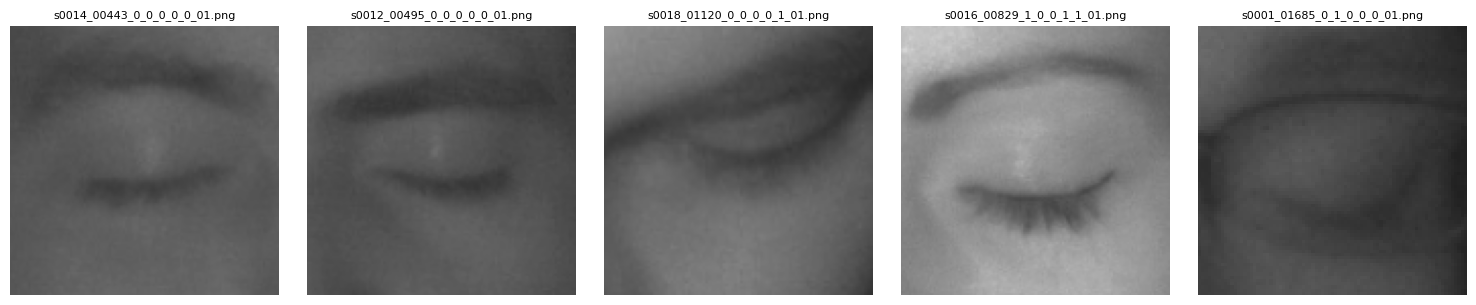

2. Dipertajam (Dengan CLAHE):


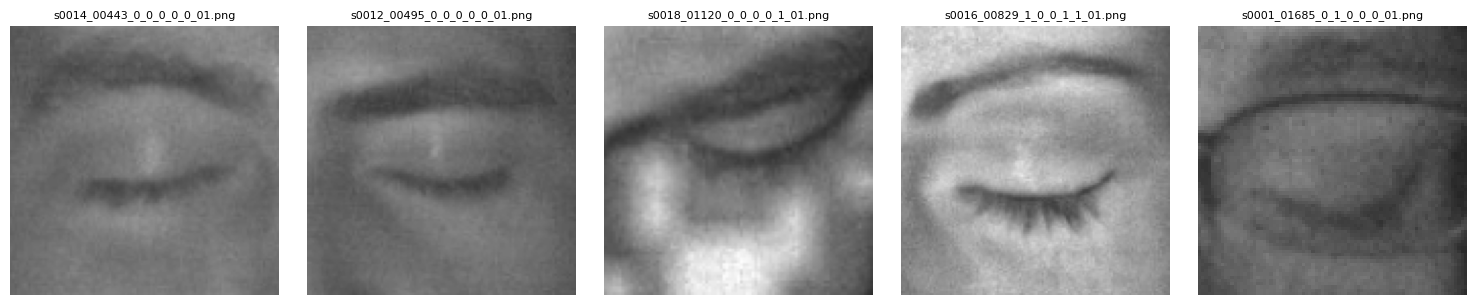

In [15]:
# --- PERBANDINGAN SEBELUM PREPROCESSING ---
def apply_clahe_to_gray(gray_img, clip_limit=2.0, tile_grid_size=(8, 8)):
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    return clahe.apply(gray_img)

def load_for_comparison(image_path):
    """
    Return: (rgb_tanpa_clahe, rgb_dengan_clahe)
    """
    gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if gray is None: return None, None
    
    # Tanpa CLAHE
    img_no_clahe = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    # Dengan CLAHE
    img_clahe = cv2.cvtColor(apply_clahe_to_gray(gray), cv2.COLOR_GRAY2RGB)
    
    return img_no_clahe, img_clahe

# --- Demo: 5 contoh gambar ---
sample_paths = get_random_image_paths(TRAIN_DIR, "Close-Eyes", 5)
no_clahe_imgs, clahe_imgs, titles = [], [], []

for p in sample_paths:
    img_no, img_c = load_for_comparison(p)
    if img_no is not None:
        no_clahe_imgs.append(img_no)
        clahe_imgs.append(img_c)
        titles.append(os.path.basename(p))

print("1. Standar (Tanpa CLAHE):")
show_image_grid(no_clahe_imgs, titles=titles, ncols=5, figsize=(15, 3))
print("2. Dipertajam (Dengan CLAHE):")
show_image_grid(clahe_imgs, titles=titles, ncols=5, figsize=(15, 3))

# Resize & Normalisasi 

Langkah:
1. Mengambil hasil gambar original yang sudah berformat RGB.
2. Melakukan resize ke 224×224 piksel.
3. Menerapkan normalisasi menggunakan `mean` dan `std` dari Notebook 01:
   - Mean (R, G, B): [0.3772, 0.3772, 0.3772]
   - Std  (R, G, B): [0.1544, 0.1544, 0.1544]
4. Menampilkan contoh hasil resize (sebelum/ sesudah normalisasi hanya sebagai cek bentuk).

1. Hasil Resize 224x224 - TANPA CLAHE:


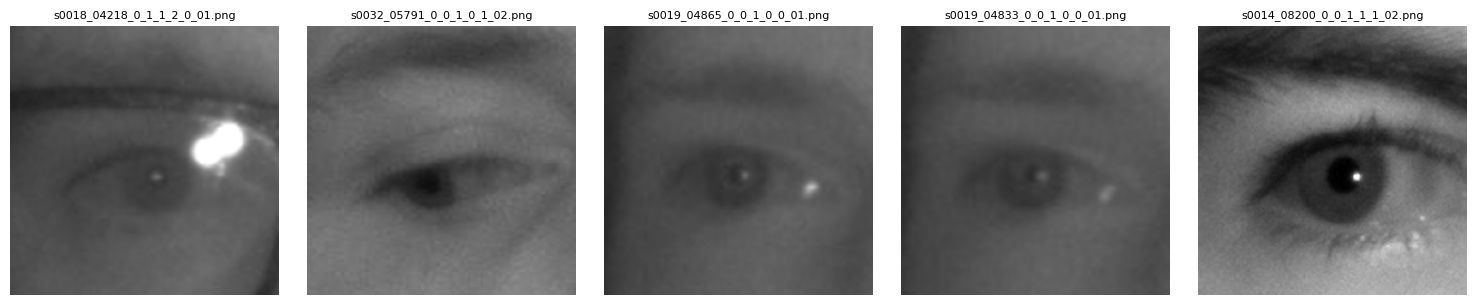

2. Hasil Resize 224x224 - DENGAN CLAHE:


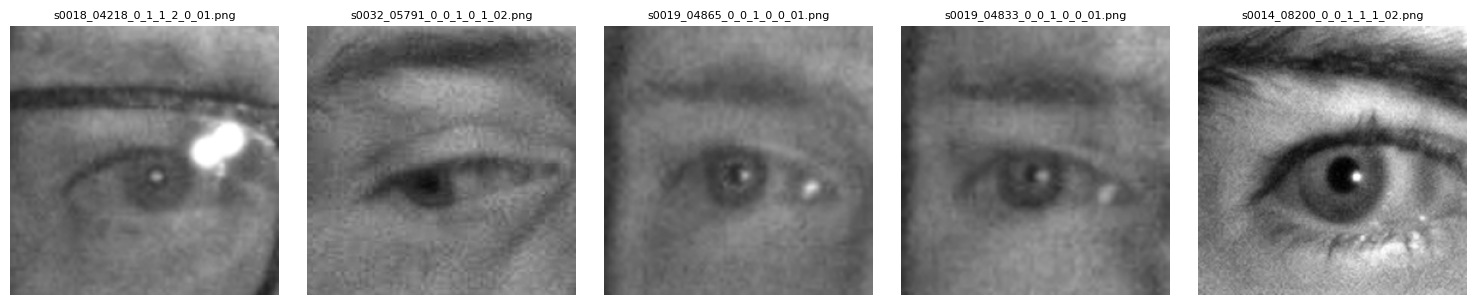

In [ ]:
MEAN = np.array( [0.3772, 0.3772, 0.3772], dtype=np.float32)
STD  = np.array( [0.1544, 0.1544, 0.1544], dtype=np.float32)

def preprocess_for_model(image_rgb, img_size=IMG_SIZE):
    """
    Proses:
    1. Resize ke img_size x img_size
    2. Konversi ke float32 dan skalakan ke [0,1]
    3. Normalisasi dengan mean & std
    Return: image_normalized (C, H, W) siap masuk model.
    """
    # Resize (OpenCV: width, height)
    resized = cv2.resize(image_rgb, (img_size, img_size), interpolation=cv2.INTER_CUBIC)
    
    # Konversi ke float [0,1]
    img = resized.astype(np.float32) / 255.0
    
    # Normalisasi channel-wise
    img = (img - MEAN) / STD
    
    # Channel first (C,H,W) untuk PyTorch
    img = np.transpose(img, (2, 0, 1))
    return img, resized


# --- Demo: Perbandingan Setelah Resize ---

demo_paths = get_random_image_paths(TRAIN_DIR, "Open-Eyes", 5)

resized_no_clahe = []
resized_clahe = []

for p in demo_paths:
    img_no_clahe, img_clahe = load_for_comparison(p)
    if img_no_clahe is None:
        continue
        
    _, res_no_clahe = preprocess_for_model(img_no_clahe)
    _, res_clahe = preprocess_for_model(img_clahe)
    
    resized_no_clahe.append(res_no_clahe)
    resized_clahe.append(res_clahe)

print("1. Hasil Resize 224x224 - TANPA CLAHE:")
show_image_grid(resized_no_clahe, titles=[os.path.basename(p) for p in demo_paths], ncols=5, figsize=(15,3))

print("2. Hasil Resize 224x224 - DENGAN CLAHE:")
show_image_grid(resized_clahe, titles=[os.path.basename(p) for p in demo_paths], ncols=5, figsize=(15,3))


Augmentasi dilakukan **on-the-fly** saat training, dengan operasi:
- Rotate ±15 derajat.
- Horizontal flip.
- Random brightness/contrast ringan.
- Resize 224×224 (untuk memastikan ukuran akhir konsisten).

Di cell ini:
1. Didefinisikan `augment_transform` yang akan dipakai di DataLoader.
2. Ditampilkan 10 contoh gambar hasil augmentasi (dari 2 gambar sumber).


# Pipeline Augmentasi (Online)

Perbandingan Augmentasi (s0013_00994_0_0_0_0_0_01.png)

1. Augmented: TANPA CLAHE


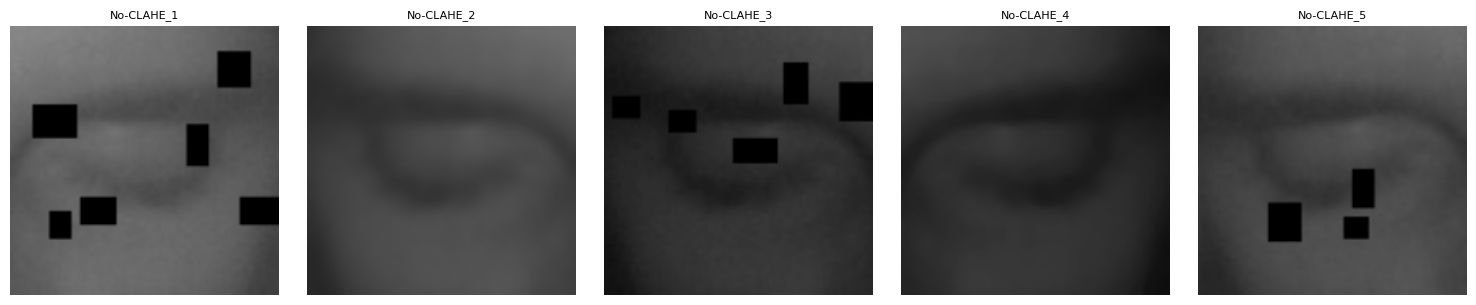

2. Augmented: DENGAN CLAHE


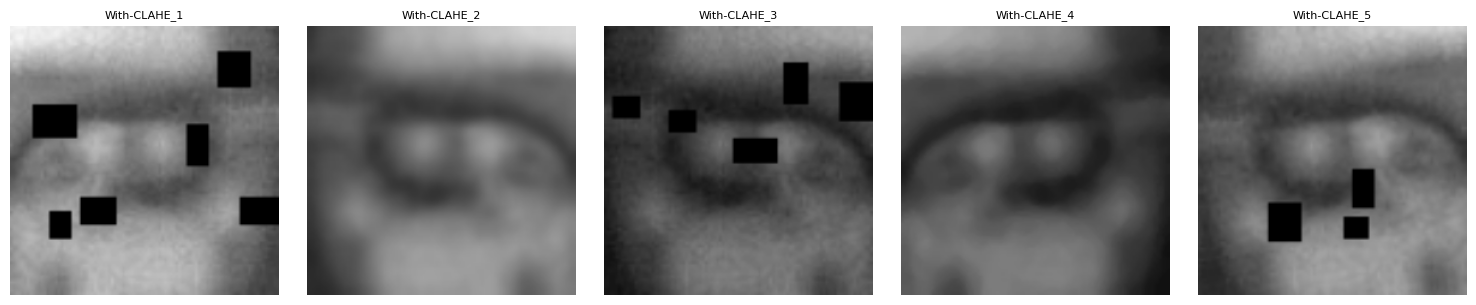

In [ ]:
# Mean & Std NTHU (dari Cell sebelumnya, diubah namanya untuk konsistensi)
NTHU_MEAN =  [0.3772, 0.3772, 0.3772]
NTHU_STD  =  [0.1544, 0.1544, 0.1544]


# Definisi pipeline augmentasi yang diinginkan
# Kita gunakan additional_targets agar augmentasi yang diberikan sama persis (sudut putar, flip, dll)
# untuk gambar Non-CLAHE maupun gambar yang memakai CLAHE 
augment_transform = A.Compose([
    # --- 1. GEOMETRIS (SAFE ZONE) ---
    # Rotate: Simulasi kepala miring saat ngantuk (Max 15 derajat biar aman)
    A.Rotate(limit=15, border_mode=cv2.BORDER_REFLECT, p=0.5),
    # HorizontalFlip: Simulasi mata kiri/kanan (Mirroring)
    A.HorizontalFlip(p=0.5),
    
    # --- 2. REAL-WORLD DRIVING CONDITION (NOVELTY 1)  ---
    # Simulasi getaran mesin & jalan rusak
    A.OneOf([
        A.MotionBlur(blur_limit=5, p=1.0),  # Efek getaran/gerak cepat
        A.MedianBlur(blur_limit=5, p=1.0),  # Efek sensor kotor/bintik
        A.GaussianBlur(blur_limit=(3, 5), p=1.0), # Efek lensa out-of-focus
    ], p=0.3),
    
    # --- 3. LOW QUALITY SENSOR / NIGHT MODE IR (NOVELTY 2)  ---
    # Simulasi kamera murah & kondisi minim cahaya
    A.OneOf([
        # ISO Noise: Bintik-bintik digital pada sensor
        A.GaussNoise(std_range=(0.1, 0.3), p=1.0), 
        # Compression: Artefak kotak-kotak akibat sinyal video jelek
        A.ImageCompression(quality_range=(75, 95), p=1.0),
    ], p=0.3),
    
    # --- 4. PENCAHAYAAN & KONTRAS (STANDARD) ---
    # Simulasi perubahan cahaya kabin (siang/malam/lampu jalan)
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
    
    # --- 5. OCCLUSION / OBSTRUKSI (NOVELTY 3 - KILLER FEATURE)  ---
    # CoarseDropout (Grid Masking): Simulasi kacamata, rambut, atau pantulan
    A.CoarseDropout(
        num_holes_range=(2, 8),         # Maksimal 8 lubang hitam
        hole_height_range=(8, 16),    
        hole_width_range=(8, 16),     
        fill=0,                         # Lubang warna hitam
        p=0.2                           # Peluang 20%
    ),
    
    # --- 6. FINALISASI ---
    A.Resize(IMG_SIZE, IMG_SIZE),
    # CATATAN: Untuk demo visualisasi di Notebook, Normalize dan ToTensorV2 
    # dinonaktifkan sementara agar gambar bisa di-plot oleh matplotlib.
    # Nanti saat masuk DataLoader untuk training, dua baris di bawah ini baru di-uncomment.
    # A.Normalize(mean=NTHU_MEAN, std=NTHU_STD),
    # ToTensorV2() 
], additional_targets={'image_clahe': 'image'})                                                                                                                                                                           

def compare_aug_with_and_without_clahe(image_path, num_aug=5):
    """
    Membandingkan hasil augmentasi antara gambar Non-CLAHE dan CLAHE.
    """
    img_no_clahe, img_clahe = load_for_comparison(image_path)
    if img_no_clahe is None:
        return [], []
    
    aug_no_clahe_list = []
    aug_clahe_list = []
    
    for _ in range(num_aug):
        # Terapkan transformasi yang identik pada kedua versi gambar sekaligus
        augmented = augment_transform(image=img_no_clahe, image_clahe=img_clahe)
        aug_no_clahe_list.append(augmented['image'])
        aug_clahe_list.append(augmented['image_clahe'])
        
    return aug_no_clahe_list, aug_clahe_list


# --- Demo: Set perbandingan dengan 5 hasil augmentasi ---
src_Close_Eyes = get_random_image_paths(TRAIN_DIR, "Close-Eyes", 1)[0]
aug_no_clahe, aug_clahe = compare_aug_with_and_without_clahe(src_Close_Eyes, num_aug=5)

print(f"Perbandingan Augmentasi ({os.path.basename(src_Close_Eyes)})\n")

print("1. Augmented: TANPA CLAHE")
show_image_grid(aug_no_clahe, titles=[f"No-CLAHE_{i+1}" for i in range(5)], ncols=5, figsize=(15,3))

print("2. Augmented: DENGAN CLAHE")
show_image_grid(aug_clahe, titles=[f"With-CLAHE_{i+1}" for i in range(5)], ncols=5, figsize=(15,3))

Perbandingan Augmentasi (s0036_02357_1_0_1_0_0_01.png)

1. Augmented: TANPA CLAHE


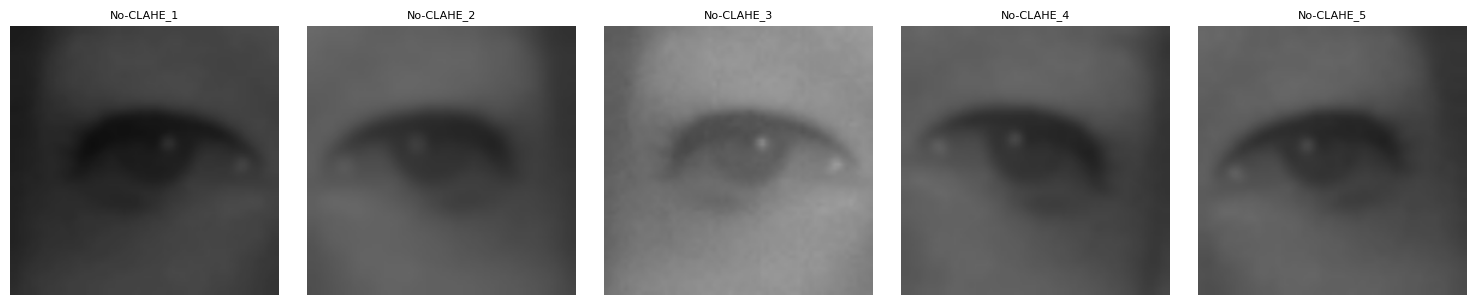

2. Augmented: DENGAN CLAHE


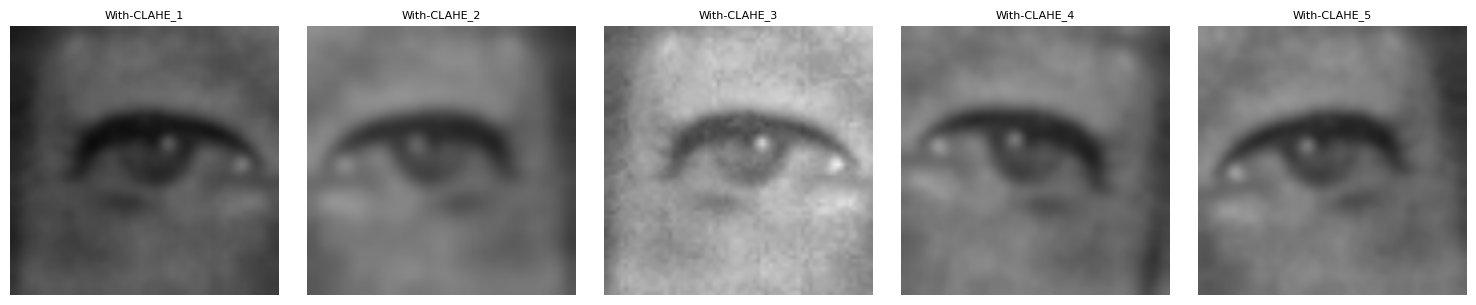

In [ ]:
# Mean & Std NTHU (dari Cell sebelumnya, diubah namanya untuk konsistensi)
NTHU_MEAN =  [0.3772, 0.3772, 0.3772]
NTHU_STD  =  [0.1544, 0.1544, 0.1544]


# Definisi pipeline augmentasi yang diinginkan
# Kita gunakan additional_targets agar augmentasi yang diberikan sama persis (sudut putar, flip, dll)
# untuk gambar Non-CLAHE maupun gambar yang memakai CLAHE 
augment_transform = A.Compose([
    # --- 1. GEOMETRIS (SAFE ZONE) ---
    # Rotate: Simulasi kepala miring saat ngantuk (Max 15 derajat biar aman)
    A.Rotate(limit=15, border_mode=cv2.BORDER_REFLECT, p=0.5),
    # HorizontalFlip: Simulasi mata kiri/kanan (Mirroring)
    A.HorizontalFlip(p=0.5),
    
    # --- 2. REAL-WORLD DRIVING CONDITION (NOVELTY 1)  ---
    # Simulasi getaran mesin & jalan rusak
    A.OneOf([
        A.MotionBlur(blur_limit=5, p=1.0),  # Efek getaran/gerak cepat
        A.MedianBlur(blur_limit=5, p=1.0),  # Efek sensor kotor/bintik
        A.GaussianBlur(blur_limit=(3, 5), p=1.0), # Efek lensa out-of-focus
    ], p=0.3),
    
    # --- 3. LOW QUALITY SENSOR / NIGHT MODE IR (NOVELTY 2)  ---
    # Simulasi kamera murah & kondisi minim cahaya
    A.OneOf([
        # ISO Noise: Bintik-bintik digital pada sensor
        A.GaussNoise(std_range=(0.1, 0.3), p=1.0), 
        # Compression: Artefak kotak-kotak akibat sinyal video jelek
        A.ImageCompression(quality_range=(75, 95), p=1.0),
    ], p=0.3),
    
    # --- 4. PENCAHAYAAN & KONTRAS (STANDARD) ---
    # Simulasi perubahan cahaya kabin (siang/malam/lampu jalan)
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
    
    # --- 5. OCCLUSION / OBSTRUKSI (NOVELTY 3 - KILLER FEATURE)  ---
    # CoarseDropout (Grid Masking): Simulasi kacamata, rambut, atau pantulan
    A.CoarseDropout(
        num_holes_range=(2, 8),         # Maksimal 8 lubang hitam
        hole_height_range=(8, 16),    
        hole_width_range=(8, 16),     
        fill=0,                         # Lubang warna hitam
        p=0.2                           # Peluang 20%
    ),
    
    # --- 6. FINALISASI ---
    A.Resize(IMG_SIZE, IMG_SIZE),
    # CATATAN: Untuk demo visualisasi di Notebook, Normalize dan ToTensorV2 
    # dinonaktifkan sementara agar gambar bisa di-plot oleh matplotlib.
    # Nanti saat masuk DataLoader untuk training, dua baris di bawah ini baru di-uncomment.
    # A.Normalize(mean=NTHU_MEAN, std=NTHU_STD),
    # ToTensorV2() 
], additional_targets={'image_clahe': 'image'})                                                                                                                                                                           

def compare_aug_with_and_without_clahe(image_path, num_aug=5):
    """
    Membandingkan hasil augmentasi antara gambar Non-CLAHE dan CLAHE.
    """
    img_no_clahe, img_clahe = load_for_comparison(image_path)
    if img_no_clahe is None:
        return [], []
    
    aug_no_clahe_list = []
    aug_clahe_list = []
    
    for _ in range(num_aug):
        # Terapkan transformasi yang identik pada kedua versi gambar sekaligus
        augmented = augment_transform(image=img_no_clahe, image_clahe=img_clahe)
        aug_no_clahe_list.append(augmented['image'])
        aug_clahe_list.append(augmented['image_clahe'])
        
    return aug_no_clahe_list, aug_clahe_list


# --- Demo: Set perbandingan dengan 5 hasil augmentasi ---
src_Open_Eyes = get_random_image_paths(TRAIN_DIR, "Open-Eyes", 1)[0]
aug_no_clahe, aug_clahe = compare_aug_with_and_without_clahe(src_Open_Eyes, num_aug=5)

print(f"Perbandingan Augmentasi ({os.path.basename(src_Open_Eyes)})\n")

print("1. Augmented: TANPA CLAHE")
show_image_grid(aug_no_clahe, titles=[f"No-CLAHE_{i+1}" for i in range(5)], ncols=5, figsize=(15,3))

print("2. Augmented: DENGAN CLAHE")
show_image_grid(aug_clahe, titles=[f"With-CLAHE_{i+1}" for i in range(5)], ncols=5, figsize=(15,3))

# Tanpa CLAHE adalah pilihan terbaik untuk arsitektur Swin Transformer pada Dataset NTHU. Model Transformer bekerja dengan mencari letak atensinya sendiri antar-patch gambar. Penambahan filter spasial (handcrafted feature) seperti CLAHE justru berisiko menyuntikkan artificial noise dan merusak sinyal asli tekstur mata, terutama ketika dikombinasikan dengan augmentasi level-kasar (seperti ISO noise / blur / video compression).

## 5. Ringkasan Pipeline Preprocessing (Tanpa CLAHE)

Berdasarkan pengujian di atas, pipeline yang akan dipakai untuk training adalah:

1. Load gambar dari dataset (grayscale).
2. Konversi ke RGB 3-channel (mengabaikan CLAHE).
3. Online Augmentation (Rotate ±15°, HorizontalFlip, Brightness/Contrast).
4. Resize ke 224×224.
5. Konversi ke float [0,1] dan normalisasi dengan:
- NTHU_MEAN =  [0.3772, 0.3772, 0.3772]
- NTHU_STD  =  [0.1544, 0.1544, 0.1544]


6. Susunan channel (C,H,W) siap masuk ke model Swin Transformer.

Pipeline ini **tidak menyimpan file baru** ke disk; semua operasi dilakukan on-the-fly saat training,
dengan contoh visual (dan augmentasi) telah diverifikasi di notebook ini.